### Student Performance Prediction System (ML Project)

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load dataset
df = pd.read_csv("student_performance_dataset.csv")

In [10]:
df.head()

,hours_study,attendance,internal_marks,previous_cgpa,participation,final_score
0,4.745071,83.577874,17.027862,7.756989,2,37.582168
1,3.792604,85.607845,22.003125,6.077835,3,37.710752
2,4.971533,90.830512,25.026218,7.869606,2,44.441500
3,6.284545,90.538021,25.234903,8.355638,1,43.184269
4,3.648770,66.223306,22.749673,7.413435,3,32.983929


In [11]:
df.shape

(200, 6)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hours_study     200 non-null    float64
 1   attendance      200 non-null    float64
 2   internal_marks  200 non-null    float64
 3   previous_cgpa   200 non-null    float64
 4   participation   200 non-null    int64  
 5   final_score     200 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 9.5 KB


In [13]:
df.describe()

,hours_study,attendance,internal_marks,previous_cgpa,participation,final_score
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,3.938844,80.720650,24.192285,7.008967,3.020000,38.084932
std,1.396506,9.434533,4.319208,1.019574,1.456091,5.996400
min,0.070382,50.000000,12.641777,4.303113,1.000000,19.334343
25%,2.942308,73.941625,21.030608,6.293531,2.000000,34.565497
50%,3.993712,80.788393,24.612000,7.022262,3.000000,38.728518
75%,4.751279,86.872311,27.860441,7.685177,4.000000,41.830238
max,8.080254,100.000000,30.000000,9.632382,5.000000,51.535428


In [7]:
# Split data
X = df.drop("final_score", axis=1)
y = df["final_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [9]:
# Evaluate
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("MSE:", mse)

R² Score: 0.22948773486638974
MSE: 20.334265089272385


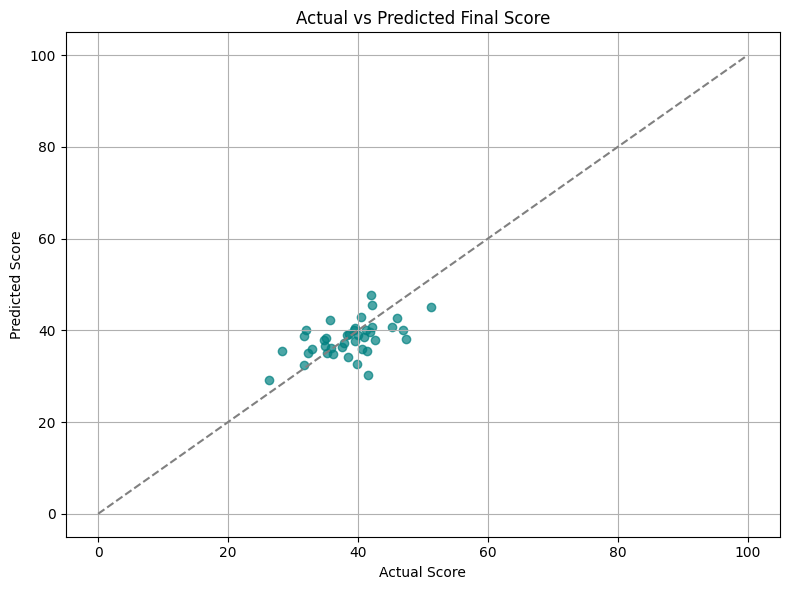

In [14]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([0, 100], [0, 100], '--', color='gray')
plt.title("Actual vs Predicted Final Score")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.grid(True)
plt.tight_layout()
plt.show()